In [1]:
import signal
import grpc
import numpy as np
from time import sleep
from concurrent import futures

from interfaces.rtde_socket_client import RTDESocketClient, rtde_data
from interfaces.control_socket_client import ControlSocketClient, control_data, common_data

ip = '192.168.0.144'

control = ControlSocketClient(ip)
rtde = RTDESocketClient(ip)

[INFO] 2024-02-01 19:23:53,545, Logger Started


### Test TELE_JOINT_ABSOLUTE 

In [2]:
control.StartTeleOp(control_data.TeleMethod.TELE_JOINT_ABSOLUTE)

{'msg': 'TeleOp Enabled', 'code': '0'}

In [3]:
control_dat = rtde.GetControlData()
vals = control_dat['q']
print(vals)

[-0.006310329, -0.011712697, -86.29075, 0.009300307, -94.923836, -0.002338674]


In [4]:
for _ in range(100):
    sleep(0.01)
    vals[0] -= 0.5
    control.MoveTeleJAbs(vals)

In [5]:
control.StopTeleOp()

{'msg': 'TeleOp Stop Requested', 'code': '0'}

### Test TELE_JOINT_RELATIVE

In [6]:
control.StartTeleOp(control_data.TeleMethod.TELE_JOINT_RELATIVE)

{'msg': 'TeleOp Enabled', 'code': '0'}

In [7]:
control_dat = rtde.GetControlData()
control_dat['q']
vals = [0] * 6
print(vals)

[0, 0, 0, 0, 0, 0]


In [8]:
for _ in range(100):
    sleep(0.01)
    vals[5] += 0.5
    control.MoveTeleJRel(vals)

In [9]:
control.StopTeleOp()

{'msg': 'TeleOp Stop Requested', 'code': '0'}

### Test TELE_TASK_ABSOLUTE 

In [10]:
control.StartTeleOp(control_data.TeleMethod.TELE_TASK_ABSOLUTE)

{'msg': 'TeleOp Enabled', 'code': '0'}

In [11]:
control_dat = rtde.GetControlData()
vals = control_dat['p']
print(vals)

[81.831055, -383.07407, 544.5683, -179.06378, -0.7952001, 80.23283]


In [12]:
for _ in range(100):
    sleep(0.01)
    vals[0] += 0.5
    control.MoveTeleLAbs(vals)

In [13]:
control.StopTeleOp()

{'msg': 'TeleOp Stop Requested', 'code': '0'}

### Test TELE_TASK_RELATIVE

In [14]:
control.StartTeleOp(control_data.TeleMethod.TELE_TASK_RELATIVE)

{'msg': 'TeleOp Enabled', 'code': '0'}

In [15]:
control_dat = rtde.GetControlData()
vals = [0] * 6
print(vals)

[0, 0, 0, 0, 0, 0]


In [16]:
for _ in range(100):
    sleep(0.01)
    vals[0] -= 0.5
    control.MoveTeleLRel(vals)

In [17]:
control.StopTeleOp()

{'msg': 'TeleOp Stop Requested', 'code': '0'}

### Test TELE_TASK_TCP

In [18]:
control.StartTeleOp(control_data.TeleMethod.TELE_TASK_TCP)

{'msg': 'TeleOp Enabled', 'code': '0'}

In [19]:
control_dat = rtde.GetControlData()
vals = [0] * 6
print(vals)

[0, 0, 0, 0, 0, 0]


In [20]:
for _ in range(50):
    sleep(0.01)
    vals[0] += 2
    control.MoveTeleLTCP(vals)

In [21]:
control.StopTeleOp()

{'msg': 'TeleOp Stop Requested', 'code': '0'}

## Plot Joint Stop Curve

In [33]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [34]:
control.StartTeleOp(control_data.TeleMethod.TELE_JOINT_ABSOLUTE)
control_dat = rtde.GetControlData()
vals = control_dat['q']
print(vals)
tvec = []
qvec = []
qdvec = []
t0 = time.time()
for _ in range(100):
    sleep(0.01)
    vals[0] += 0.5
    qvec.append(rtde.GetControlData()['q'][0])
    qdvec.append(vals[0])
    tvec.append(time.time() - t0)
    control.MoveTeleJAbs(vals)
t1 = time.time() - t0
control.StopTeleOp()
while rtde.GetControlData()['op_state'] == common_data.TELE_OP:
    sleep(0.01)
    qvec.append(rtde.GetControlData()['q'][0])
    qdvec.append(vals[0])
    tvec.append(time.time() - t0)

[12.184292, -0.62104535, -85.39845, 0.24817136, -95.16216, 62.5053]


5.444807052612305

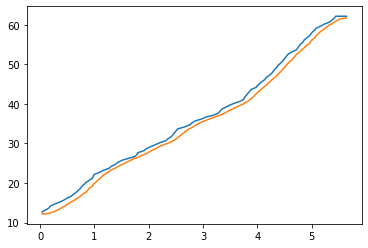

In [35]:
plt.plot(tvec, qdvec)
plt.plot(tvec, qvec)
t1

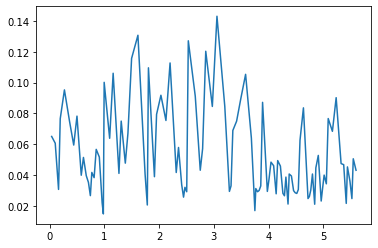

In [36]:
plt.plot(tvec[:-1], np.subtract(tvec[1:], tvec[:-1]))

## Plot Task Stop Curve

In [37]:
control.StartTeleOp(control_data.TeleMethod.TELE_TASK_ABSOLUTE)
control_dat = rtde.GetControlData()
vals = control_dat['p']
print(vals)
tvec = []
qvec = []
qdvec = []
t0 = time.time()
for _ in range(50):
    sleep(0.01)
    vals[0] += 2
    control.MoveTeleLAbs(vals)
    qvec.append(rtde.GetControlData()['p'][0])
    qdvec.append(vals[0])
    tvec.append(time.time() - t0)
t1 = time.time() - t0
control.StopTeleOp()
while rtde.GetControlData()['op_state'] == common_data.TELE_OP:
    sleep(0.01)
    qvec.append(rtde.GetControlData()['p'][0])
    qdvec.append(vals[0])
    tvec.append(time.time() - t0)

[329.01215, 219.62326, 545.5213, -179.0659, -0.7664201, 179.19888]


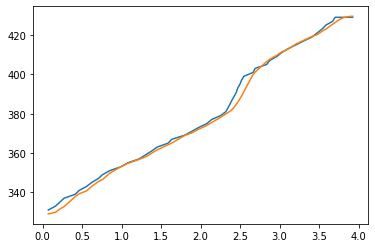

In [38]:
plt.plot(tvec, qdvec)
plt.plot(tvec, qvec)

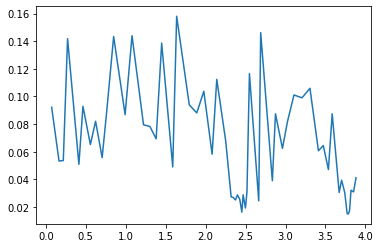

In [39]:
plt.plot(tvec[:-1], np.subtract(tvec[1:], tvec[:-1]))

## Device protocol

In [40]:
control.GetTeleOpDevice()

{'name': 'tele', 'type': 1, 'ip': '192.168.0.124', 'port': 20500}

In [41]:
control.GetTeleOpState()

{'mode': 0, 'method': 0}

In [ ]:
control.ConnectTeleOpDevice(
    name="tele", type=control_data.TeleOpDevice.VIVE,
    ip="192.168.0.95", port=20500
)

In [ ]:
control.ReadTeleOpInput() 

In [ ]:
control.DisConnectTeleOpDevice()

In [ ]:
control.GetTeleFileList()

In [ ]:
control.SaveTeleMotion(name="tele")

In [ ]:
control.LoadTeleMotion(name="tele")

### Test Record

In [ ]:
resp = control.StartTeleOp(method=control_data.TeleMethod.TELE_RECORD_ABSOLUTE,
                           mode=control_data.TeleMode.TELE_RECORD)

In [ ]:
control_dat = rtde.GetControlData()
jpos = list(control_dat['q'])
tpos = list(control_dat['p'])
vals = tpos
vals

In [ ]:
control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[0] -= 1
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[0] += 1
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[1] -= 1
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[1] += 1
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[2] -= 1
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[2] += 1
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[3] -= 0.3
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[3] += 0.3
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[4] -= 0.3
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[4] += 0.3
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[5] -= 0.3
    control.MoveTeleLRec(vals)

In [ ]:
for _ in range(100):
    sleep(0.01)
    vals[5] += 0.3
    control.MoveTeleLRec(vals)

In [ ]:
control.StopTeleOp()

### Test Play

In [ ]:
control.StartTeleOp(method=control_data.TeleMethod.TELE_RECORD_ABSOLUTE,
                    mode=control_data.TeleMode.TELE_PLAY)

In [ ]:
control.StopTeleOp()

### Test Save & Load

In [ ]:
control.SaveTeleMotion(name="tele")

In [ ]:
control.LoadTeleMotion(name="tele")

## Keyboard example

In [ ]:
import keyboard
import time
from IPython.display import clear_output

key_pressed = {"1": False, "2": False}


while True:
    clear_output(wait=True)
    time.sleep(0.01)
    if keyboard.is_pressed("q"):
        print("q")
        break
        
    control_dat = rtde.GetControlData()
    vals = control_dat['q']

    # "1" 키에 대한 로직
    if keyboard.is_pressed("1"):
        if not key_pressed["1"]:  # "1"이 최초로 눌러졌을 때
            key_pressed["1"] = True
            control.StartTeleOp(control_data.TeleMethod.TELE_JOINT_ABSOLUTE)
            # 여기에 최초로 눌렀을 때의 로직을 추가하세요.

        # "1"을 누르고 있는 동안의 로직
        # 예를 들어, vals 값을 변경하는 로직
        vals[0] -= 5
        print("[{:.6f}, {:.6f}]".format(vals[0], vals[1]))
        control.MoveTeleJ(vals)
    else:
        if key_pressed["1"]:  # "1"을 누르고 있던 상태에서 뗐을 때
            key_pressed["1"] = False
            control.StopTeleOp()
            # 여기에 키를 뗐을 때의 로직을 추가하세요.
            
    if keyboard.is_pressed("2"):
        if not key_pressed["2"]:  # "1"이 최초로 눌러졌을 때
            key_pressed["2"] = True
            control.StartTeleOp(control_data.TeleMethod.TELE_JOINT_ABSOLUTE)
            # 여기에 최초로 눌렀을 때의 로직을 추가하세요.

        # "1"을 누르고 있는 동안의 로직
        # 예를 들어, vals 값을 변경하는 로직
        vals[0] += 5
        print("[{:.6f}, {:.6f}]".format(vals[0], vals[1]))
        control.MoveTeleJ(vals)
    else:
        if key_pressed["2"]:  # "1"을 누르고 있던 상태에서 뗐을 때
            key_pressed["2"] = False
            control.StopTeleOp()
            # 여기에 키를 뗐을 때의 로직을 추가하세요.


        